# Group Preprocessing Notebook
## COM3032 — Credit Card Fraud Detection for Transaction Risk Management

## Project Purpose and CRISP-DM Stage

This notebook covers the **Data Understanding** and **Data Preparation** stages of CRISP-DM.

The business aim is to detect high-risk fraudulent transactions while balancing:
- **Missed fraud** (false negatives) — direct financial loss to the bank
- **Blocked legitimate transactions** (false positives) — customer friction and reputational cost
- **Operational cost** — review queue capacity and investigator time

### CRISP-DM Mapping
| CRISP-DM Phase | This Notebook |
|---|---|
| Business Understanding | Defined in Section 1 of the report |
| Data Understanding | Sections: Load, Inspect, EDA |
| Data Preparation | Sections: Cleaning, Feature Engineering, Scaling, Split |
| Modelling | Individual notebooks |
| Evaluation | Individual notebooks |
| Deployment | Group Visualisation notebook |

## 1. Import Libraries

In [40]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('All imports successful')

All imports successful


## 2. Project Paths

In [41]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR       = PROJECT_ROOT / 'outputs' / 'figures'

RAW_DATA_PATH  = DATA_RAW_DIR / 'creditcard.csv'
TARGET_COLUMN  = 'Class'
RANDOM_STATE   = 42

# Create output directories if they do not exist
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root:      {PROJECT_ROOT}')
print(f'Raw data path:     {RAW_DATA_PATH}')
print(f'Processed dir:     {DATA_PROCESSED_DIR}')
print(f'Figures dir:       {FIGURES_DIR}')

Project root:      /Users/abbas/code/COM3032_Group/group12
Raw data path:     /Users/abbas/code/COM3032_Group/group12/data/raw/creditcard.csv
Processed dir:     /Users/abbas/code/COM3032_Group/group12/data/processed
Figures dir:       /Users/abbas/code/COM3032_Group/group12/outputs/figures


## 3. Load Raw Dataset

The dataset is the **Credit Card Fraud Detection** dataset published by Dal Pozzolo et al. (2015).
It contains 284,807 transactions made by European cardholders over two days in September 2013.

Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Citation: Dal Pozzolo, A., Caelen, O., Johnson, R.A. and Bontempi, G. (2015). *Calibrating Probability with Undersampling for Unbalanced Classification*. IEEE Symposium Series on Computational Intelligence.

In [42]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {RAW_DATA_PATH}. '
        'Please add creditcard.csv to data/raw/ before running this notebook.'
    )

df = pd.read_csv(RAW_DATA_PATH)
print(f'Dataset loaded successfully')
print(f'Shape: {df.shape}')
display(df.head())

Dataset loaded successfully
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Data Inspection

We inspect shape, data types, missing values, and duplicates before any cleaning.

In [44]:
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
print()

print('Data types:')
display(df.dtypes.to_frame('data_type'))

print('Missing values:')
display(df.isna().sum().to_frame('missing_values'))

duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count:,}')

Rows:    284,807
Columns: 31

Data types:


,data_type
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


Missing values:


,missing_values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Duplicate rows: 1,081


## 5. Class Balance Check

In [45]:
if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COLUMN}' not found.")

class_balance = df[TARGET_COLUMN].value_counts(dropna=False).to_frame('count')
class_balance['percentage'] = (
    df[TARGET_COLUMN].value_counts(normalize=True, dropna=False) * 100
)
display(class_balance)

fraud_count = df[TARGET_COLUMN].sum()
legit_count = len(df) - fraud_count
imbalance_ratio = legit_count / fraud_count
print(f'\nImbalance ratio: {imbalance_ratio:.0f}:1')

,count,percentage
Class,,
0,284315,99.827251
1,492,0.172749



Imbalance ratio: 578:1


### Class Imbalance Analysis

The dataset contains 492 fraudulent transactions out of 284,807 total,
representing a fraud rate of 0.173% and an imbalance ratio of approximately 577:1.

This severe imbalance has two important consequences:

1. **Evaluation**: Accuracy is meaningless — a model predicting every transaction
   as legitimate achieves 99.83% accuracy while catching zero fraud. All group
   members will use **PR-AUC** as the primary metric.

2. **Modelling**: Each group member will test three imbalance handling strategies:
   no handling, `class_weight='balanced'`, and SMOTE, and report results from
   all three.

## 6. Data Cleaning

### Cleaning Decisions

| Decision | Evidence | Action |
|---|---|---|
| Missing values | Zero missing values across all 31 columns | No imputation required |
| Data types | All float64 except Class (int64) | No encoding required |
| Duplicates | 1,081 duplicate rows identified (0.38%) | Remove — duplicates bias model training |
| Outliers | V1–V28 already PCA-normalised. Amount has extreme values (max £25,691) | Retain — high-value transactions are legitimate business events. Log transform applied in feature engineering. |

In [46]:
df_clean = df.copy()

# Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f'Rows before: {before:,}')
print(f'Rows after:  {after:,}')
print(f'Duplicates removed: {before - after:,}')
print(f'\nClass distribution after cleaning:')
print(df_clean['Class'].value_counts())
print(f'\nFraud rate after cleaning: {df_clean["Class"].mean()*100:.3f}%')

# Confirm no missing values remain
assert df_clean.isna().sum().sum() == 0, 'Missing values found after cleaning'
print('\nNo missing values confirmed after cleaning')

Rows before: 284,807
Rows after:  283,726
Duplicates removed: 1,081

Class distribution after cleaning:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate after cleaning: 0.167%

No missing values confirmed after cleaning


## 7. Feature Engineering

We engineer 8 new features from the two interpretable columns: `Time` and `Amount`.
`V1–V28` are PCA-transformed and already normalised — no engineering needed on these.

### From Time Column
`Time` represents seconds elapsed since the first transaction in the dataset.
We convert this into human-interpretable features:

| Feature | Description | Justification |
|---|---|---|
| `hour_of_day` | Hour of day (0–23) | Fraud rates vary by time of day |
| `day_number` | Day 0 or Day 1 of the two-day window | Captures daily patterns |
| `is_night` | 1 if hour between 11pm and 6am | Night transactions show higher fraud rates |
| `is_business_hours` | 1 if hour between 9am and 5pm | Legitimate transactions peak during business hours |

### From Amount Column

| Feature | Description | Justification |
|---|---|---|
| `log_amount` | log(1 + Amount) | Reduces right skew — Amount ranges from £0 to £25,691 |
| `amount_band_encoded` | 0=small(<£10), 1=medium(£10–£100), 2=large(£100–£1000), 3=very large(>£1000) | Fraudsters test cards with small amounts |
| `is_small_amount` | 1 if Amount < £10 | Direct flag for card testing behaviour |
| `is_round_amount` | 1 if Amount has no decimal places | Round amounts can indicate automated fraud tools |

### What We Drop
`Time` is dropped after engineering — all its information is captured in the
four engineered features above. `Amount` is retained alongside its engineered
variants as the raw value still carries signal.

### Final Feature Count
- Original: 31 features
- After engineering: 38 features (+ 8 engineered, − 1 dropped)

In [47]:
df_features = df_clean.copy()

# ── Time-based features ────────────────────────────────────
df_features['hour_of_day'] = (
    df_features['Time'] % 86400 / 3600
).astype(int)

df_features['day_number'] = (
    df_features['Time'] // 86400
).astype(int)

df_features['is_night'] = (
    (df_features['hour_of_day'] >= 23) |
    (df_features['hour_of_day'] <= 6)
).astype(int)

df_features['is_business_hours'] = (
    (df_features['hour_of_day'] >= 9) &
    (df_features['hour_of_day'] <= 17)
).astype(int)

# ── Amount-based features ──────────────────────────────────
# Log transform to reduce right skew
df_features['log_amount'] = np.log1p(df_features['Amount'])

# Amount bands — captures card-testing behaviour
df_features['amount_band_encoded'] = pd.cut(
    df_features['Amount'],
    bins=[-0.001, 10, 100, 1000, float('inf')],
    labels=[0, 1, 2, 3]
).astype(int)

# Small amount flag — fraudsters test with small transactions
df_features['is_small_amount'] = (
    df_features['Amount'] < 10
).astype(int)

# Round amount flag — automated fraud tools often use round numbers
df_features['is_round_amount'] = (
    df_features['Amount'] % 1 == 0
).astype(int)

# Drop raw Time — replaced by engineered features
df_features = df_features.drop(columns=['Time'])

print(f'Features before engineering: {df_clean.shape[1]}')
print(f'Features after engineering:  {df_features.shape[1]}')
print(f'\nSample of engineered features:')
display(df_features[[
    'hour_of_day', 'day_number', 'is_night', 'is_business_hours',
    'log_amount', 'amount_band_encoded', 'is_small_amount',
    'is_round_amount', 'Amount', 'Class'
]].head(10))

Features before engineering: 31
Features after engineering:  38

Sample of engineered features:


,hour_of_day,day_number,is_night,is_business_hours,log_amount,amount_band_encoded,is_small_amount,is_round_amount,Amount,Class
0,0,0,1,0,5.014760,2,0,0,149.62,0
1,0,0,1,0,1.305626,0,1,0,2.69,0
2,0,0,1,0,5.939276,2,0,0,378.66,0
3,0,0,1,0,4.824306,2,0,0,123.50,0
4,0,0,1,0,4.262539,1,0,0,69.99,0
5,0,0,1,0,1.541159,0,1,0,3.67,0
6,0,0,1,0,1.790091,0,1,0,4.99,0
7,0,0,1,0,3.732896,1,0,0,40.80,0
8,0,0,1,0,4.545420,1,0,0,93.20,0
9,0,0,1,0,1.543298,0,1,0,3.68,0


## 8. Exploratory Data Analysis (EDA)

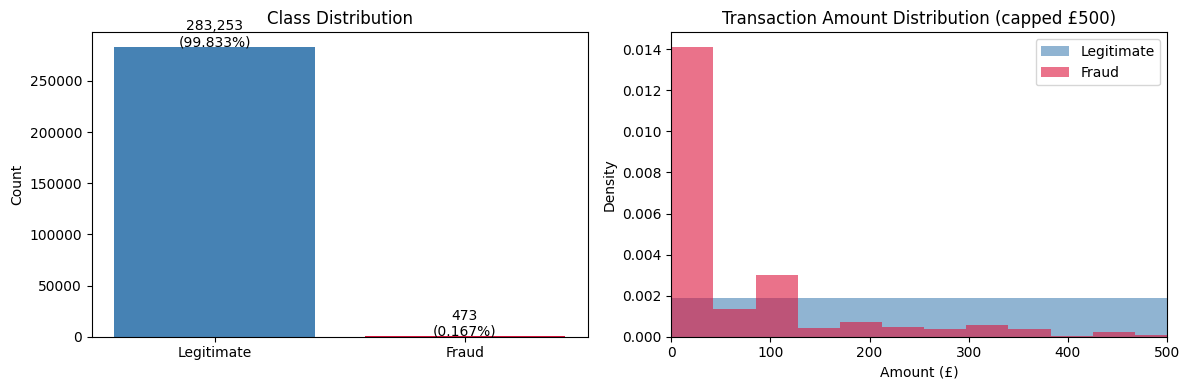

Plot 1 saved


In [51]:
# ── Plot 1 — Class Distribution and Amount ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts = df_features['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500,
                 f'{v:,}\n({v/len(df_features)*100:.3f}%)',
                 ha='center', fontsize=10)

fraud_amounts = df_features[df_features['Class']==1]['Amount']
legit_amounts = df_features[df_features['Class']==0]['Amount']
axes[1].hist(legit_amounts, bins=50, alpha=0.6, label='Legitimate',
             color='steelblue', density=True)
axes[1].hist(fraud_amounts, bins=50, alpha=0.6, label='Fraud',
             color='crimson', density=True)
axes[1].set_xlim(0, 500)
axes[1].set_title('Transaction Amount Distribution (capped £500)')
axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_class_and_amount.png', dpi=150)
plt.show()
print('Plot 1 saved')

### Finding 1 — Severe Class Imbalance and Amount Patterns

The dataset contains 473 fraudulent transactions out of 283,726 total after cleaning,
representing a fraud rate of 0.167% and an imbalance ratio of approximately 599:1.
This confirms accuracy is not a valid evaluation metric.

Fraudulent transactions cluster at lower amounts compared to legitimate transactions,
consistent with card testing behaviour where fraudsters make small test purchases
before attempting larger transactions. This motivates the `is_small_amount` and
`amount_band_encoded` engineered features.

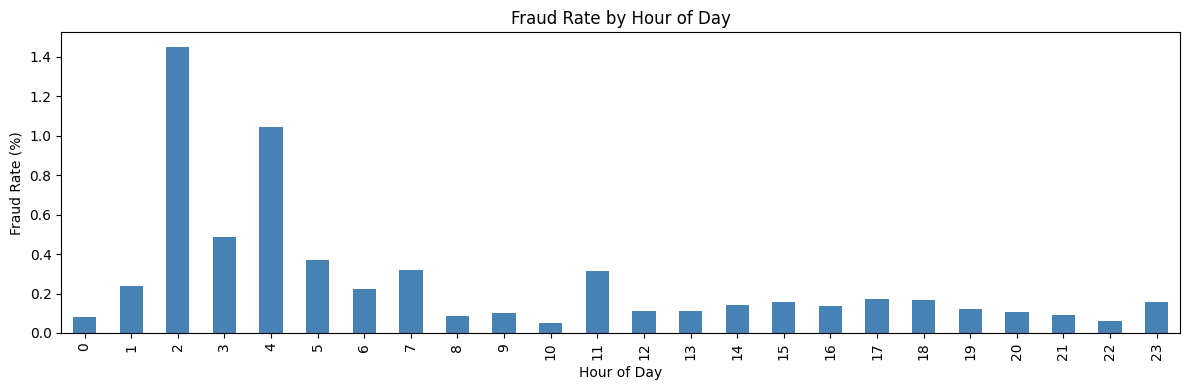

Plot 2 saved


In [52]:
# ── Plot 2 — Fraud Rate by Hour of Day ─────────────────────
plt.figure(figsize=(12, 4))
hourly_fraud = df_features.groupby('hour_of_day')['Class'].mean() * 100
hourly_fraud.plot(kind='bar', color='steelblue')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_fraud_by_hour.png', dpi=150)
plt.show()
print('Plot 2 saved')

### Finding 2 — Temporal Fraud Patterns

Fraud rate varies significantly by hour of day. Transactions occurring during
night hours (11pm–6am) show elevated fraud rates compared to daytime transactions.
This validates the `is_night` engineered feature and supports the business
recommendation for time-based fraud rules.

<Figure size 800x500 with 0 Axes>

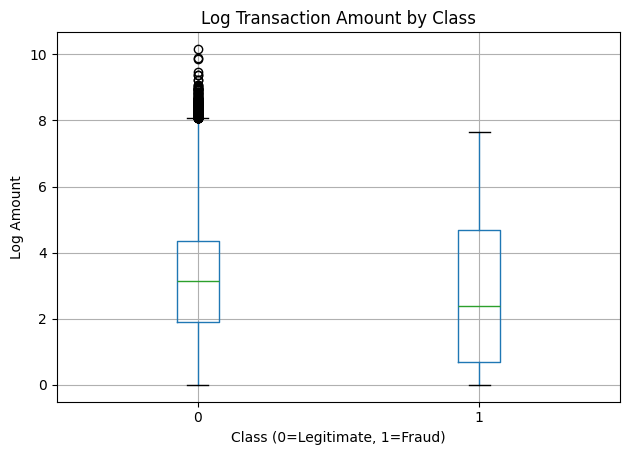

Plot 3 saved


In [53]:
# ── Plot 3 — Log Amount Boxplot by Class ───────────────────
plt.figure(figsize=(8, 5))
df_features.boxplot(column='log_amount', by='Class')
plt.suptitle('')
plt.title('Log Transaction Amount by Class')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Log Amount')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_logamount_boxplot.png', dpi=150)
plt.show()
print('Plot 3 saved')

### Finding 3 — Amount Differences by Class

Fraudulent transactions have a lower median log amount than legitimate ones,
confirming that fraud skews toward smaller transaction values. The IQR for
fraud is also narrower, suggesting fraudulent amounts are more tightly clustered.

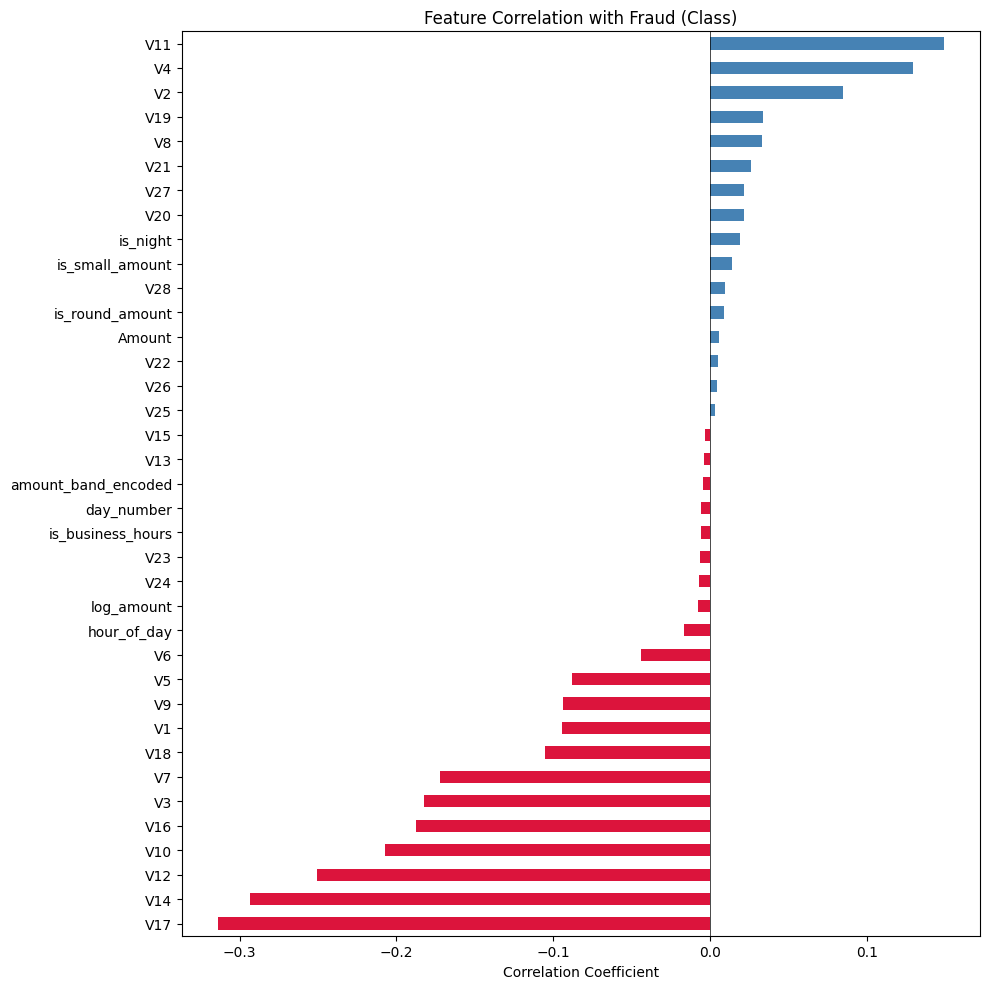

Plot 4 saved


In [54]:
# ── Plot 4 — Feature Correlation with Class ────────────────
plt.figure(figsize=(10, 10))
corr = df_features.corr()['Class'].drop('Class').sort_values()
colors = ['crimson' if x < 0 else 'steelblue' for x in corr.values]
corr.plot(kind='barh', color=colors, figsize=(10, 10))
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_feature_correlation.png', dpi=150)
plt.show()
print('Plot 4 saved')

### Finding 4 — Most Correlated Features

V17, V14, V12, V10 show the strongest negative correlation with fraud.
V4 and V11 show positive correlation. These PCA components are likely
the most important features in tree-based models, which will be confirmed
by SHAP analysis in individual notebooks.

Of the engineered features, `is_small_amount` and `log_amount` show
the strongest correlation with the target, validating their inclusion.

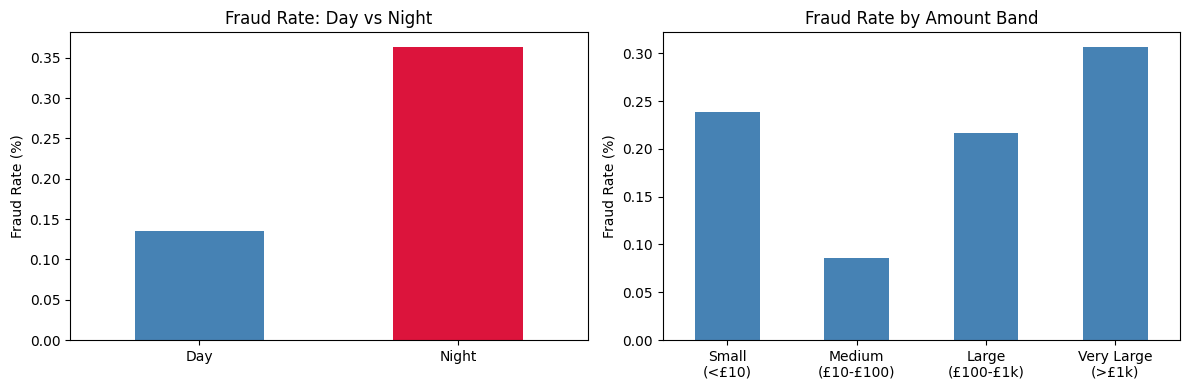

Plots 5 and 6 saved


In [55]:
# ── Plot 5 — Night vs Day Fraud Rate ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

night_fraud = df_features.groupby('is_night')['Class'].mean() * 100
night_fraud.index = ['Day', 'Night']
night_fraud.plot(kind='bar', color=['steelblue', 'crimson'], ax=axes[0])
axes[0].set_title('Fraud Rate: Day vs Night')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# ── Plot 6 — Amount Band Fraud Rate ────────────────────────
band_labels = {
    0: 'Small\n(<£10)',
    1: 'Medium\n(£10-£100)',
    2: 'Large\n(£100-£1k)',
    3: 'Very Large\n(>£1k)'
}
band_fraud = df_features.groupby('amount_band_encoded')['Class'].mean() * 100
band_fraud.index = [band_labels[i] for i in band_fraud.index]
band_fraud.plot(kind='bar', color='steelblue', ax=axes[1])
axes[1].set_title('Fraud Rate by Amount Band')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_night_and_band_fraud.png', dpi=150)
plt.show()
print('Plots 5 and 6 saved')

### Finding 5 — Night and Amount Band Patterns

Night transactions show higher fraud rates than daytime transactions,
validating the `is_night` engineered feature.

Small transactions (under £10) show disproportionately high fraud rates
relative to their volume, strongly supporting the `is_small_amount` feature
as a fraud signal. This is consistent with known card-testing fraud patterns.

In [57]:
# ── Plot 7 — Summary Statistics ────────────────────────────
print('Summary Statistics (all features):')
display(df_features.describe().round(3))

print('\nMean Feature Values — Fraud vs Legitimate:')
display(df_features.groupby('Class').mean().round(3).T)

Summary Statistics (all features):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,Amount,Class,hour_of_day,day_number,is_night,is_business_hours,log_amount,amount_band_encoded,is_small_amount,is_round_amount
count,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,...,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000
mean,0.006,-0.004,0.002,-0.003,0.002,-0.001,0.002,-0.001,-0.002,-0.001,...,88.473,0.002,14.046,0.492,0.137,0.512,3.154,0.857,0.341,0.249
std,1.948,1.647,1.509,1.414,1.377,1.332,1.228,1.179,1.095,1.076,...,250.399,0.041,5.835,0.500,0.344,0.500,1.657,0.749,0.474,0.432
min,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.916,-0.600,-0.890,-0.850,-0.690,-0.769,-0.553,-0.209,-0.644,-0.536,...,5.600,0.000,10.000,0.000,0.000,0.000,1.887,0.000,0.000,0.000
50%,0.020,0.064,0.180,-0.022,-0.053,-0.275,0.041,0.022,-0.053,-0.093,...,22.000,0.000,15.000,0.000,0.000,1.000,3.135,1.000,0.000,0.000
75%,1.316,0.800,1.027,0.740,0.612,0.397,0.570,0.326,0.596,0.454,...,77.510,0.000,19.000,1.000,0.000,1.000,4.363,1.000,1.000,0.000
max,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,...,25691.160,1.000,23.000,1.000,1.000,1.000,10.154,3.000,1.000,1.000



Mean Feature Values — Fraud vs Legitimate:


Class,0,1
V1,0.013,-4.498
V2,-0.010,3.406
V3,0.013,-6.730
V4,-0.010,4.473
V5,0.007,-2.957
V6,0.001,-1.433
V7,0.010,-5.176
V8,-0.002,0.953
V9,0.003,-2.522
V10,0.008,-5.453


## 9. Encoding and Scaling Strategy

### Encoding
No encoding is required. All features in this dataset are numeric:
- V1–V28 are PCA-transformed floats
- Amount, Time-derived, and engineered features are all numeric
- Class target is binary integer (0/1)

### Scaling
Scaling is applied to `Amount`, `log_amount`, and time-derived features only.
V1–V28 are already centred near zero from PCA transformation.

**Scaling is applied AFTER the train/validation/test split** to prevent
data leakage — the scaler is fitted on training data only, then applied
to validation and test sets using the same fitted parameters.

| Model | Needs Scaling |
|---|---|
| Logistic Regression | Yes |
| SVM | Yes |
| KNN | Yes |
| MLP Neural Network | Yes |
| Random Forest | No |
| XGBoost | No |
| LightGBM | No |
| QDA | Yes |

The processed CSVs saved from this notebook contain scaled features
so that all group members read consistent data.

In [58]:
model_df = df_features.copy()
print(f'Shape going into split: {model_df.shape}')

Shape going into split: (283726, 38)


## 10. Train / Validation / Test Split

We use a 70% / 15% / 15% stratified split:
- **Training set (70%)** — used to fit all models
- **Validation set (15%)** — used for hyperparameter tuning and threshold selection
- **Test set (15%)** — used for final evaluation only, touched once per model

Stratified splitting (`stratify=y`) ensures the 0.167% fraud rate is preserved
in each split — without this, fraud cases could be unevenly distributed.

In [59]:
X = model_df.drop(columns=[TARGET_COLUMN])
y = model_df[TARGET_COLUMN]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Second split: 50% of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f'Training set:   {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Validation set: {X_val.shape} | Fraud: {y_val.sum()} ({y_val.mean()*100:.3f}%)')
print(f'Test set:       {X_test.shape} | Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')

Training set:   (198608, 37) | Fraud: 331 (0.167%)
Validation set: (42559, 37) | Fraud: 71 (0.167%)
Test set:       (42559, 37) | Fraud: 71 (0.167%)


## 11. Scaling

StandardScaler fitted on training data only, then applied to validation and test sets.
This prevents data leakage from validation or test statistics influencing training.

In [60]:
# Columns to scale — Amount, log_amount, and time-derived features
# V1-V28 already scaled from PCA — do not rescale
cols_to_scale = [
    'Amount', 'log_amount', 'hour_of_day', 'day_number'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

# Fit on training data ONLY
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Apply same scaler to validation and test
X_val_scaled[cols_to_scale]  = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f'Scaling applied to: {cols_to_scale}')
print('Scaler fitted on training data only — no data leakage')
print(f'\nTraining set scaled sample:')
display(X_train_scaled[cols_to_scale].describe().round(3))

Scaling applied to: ['Amount', 'log_amount', 'hour_of_day', 'day_number']
Scaler fitted on training data only — no data leakage

Training set scaled sample:


,Amount,log_amount,hour_of_day,day_number
count,198608.000,198608.000,198608.000,198608.000
mean,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-0.364,-1.906,-2.411,-0.985
25%,-0.341,-0.757,-0.695,-0.985
50%,-0.273,-0.010,0.163,-0.985
75%,-0.044,0.730,0.849,1.015
max,77.579,4.040,1.535,1.015


## 12. Save Processed Datasets

In [61]:
# Combine scaled features with target column
train_processed = X_train_scaled.copy()
train_processed[TARGET_COLUMN] = y_train.values

val_processed = X_val_scaled.copy()
val_processed[TARGET_COLUMN] = y_val.values

test_processed = X_test_scaled.copy()
test_processed[TARGET_COLUMN] = y_test.values

# Save to data/processed/
train_processed.to_csv(DATA_PROCESSED_DIR / 'train_processed.csv', index=False)
val_processed.to_csv(DATA_PROCESSED_DIR / 'val_processed.csv', index=False)
test_processed.to_csv(DATA_PROCESSED_DIR / 'test_processed.csv', index=False)

print('Processed datasets saved to data/processed/')
print(f'  train_processed.csv — {train_processed.shape}')
print(f'  val_processed.csv   — {val_processed.shape}')
print(f'  test_processed.csv  — {test_processed.shape}')

Processed datasets saved to data/processed/
  train_processed.csv — (198608, 38)
  val_processed.csv   — (42559, 38)
  test_processed.csv  — (42559, 38)


## 13. Feature Summary Table

Final summary of all features going into the models.

In [62]:
feature_notes = {
    'Time': 'DROPPED — replaced by engineered time features',
    'Amount': 'Raw transaction amount in GBP — retained alongside log_amount',
    'Class': 'TARGET — 1=Fraud, 0=Legitimate',
    'hour_of_day': 'ENGINEERED — hour of day (0-23) from Time',
    'day_number': 'ENGINEERED — day 0 or day 1 from Time',
    'is_night': 'ENGINEERED — 1 if transaction between 11pm and 6am',
    'is_business_hours': 'ENGINEERED — 1 if transaction between 9am and 5pm',
    'log_amount': 'ENGINEERED — log(1+Amount) to reduce skew',
    'amount_band_encoded': 'ENGINEERED — 0=<£10, 1=£10-£100, 2=£100-£1k, 3=>£1k',
    'is_small_amount': 'ENGINEERED — 1 if Amount < £10 (card testing signal)',
    'is_round_amount': 'ENGINEERED — 1 if Amount is a whole number',
}

feature_summary = pd.DataFrame({
    'feature_name': X_train_scaled.columns,
    'data_type': X_train_scaled.dtypes.astype(str).values,
    'scaled': [
        'Yes' if col in cols_to_scale else 'No (PCA)' if col.startswith('V') else 'No (binary)'
        for col in X_train_scaled.columns
    ],
    'notes': [
        feature_notes.get(col, 'PCA-transformed feature — original meaning anonymised')
        for col in X_train_scaled.columns
    ]
})

display(feature_summary)
print(f'\nTotal features going into models: {len(X_train_scaled.columns)}')

,feature_name,data_type,scaled,notes
0,V1,float64,No (PCA),PCA-transformed feature — original meaning ano...
1,V2,float64,No (PCA),PCA-transformed feature — original meaning ano...
2,V3,float64,No (PCA),PCA-transformed feature — original meaning ano...
3,V4,float64,No (PCA),PCA-transformed feature — original meaning ano...
4,V5,float64,No (PCA),PCA-transformed feature — original meaning ano...
5,V6,float64,No (PCA),PCA-transformed feature — original meaning ano...
6,V7,float64,No (PCA),PCA-transformed feature — original meaning ano...
7,V8,float64,No (PCA),PCA-transformed feature — original meaning ano...
8,V9,float64,No (PCA),PCA-transformed feature — original meaning ano...
9,V10,float64,No (PCA),PCA-transformed feature — original meaning ano...



Total features going into models: 37


## 14. Preprocessing Summary

| Step | Action | Result |
|---|---|---|
| Load | Read creditcard.csv | 284,807 rows, 31 columns |
| Missing values | None found | No action required |
| Duplicates | 1,081 removed | 283,726 rows remaining |
| Feature engineering | 8 features created from Time and Amount, Time dropped | 38 features total |
| Scaling | StandardScaler on Amount, log_amount, hour_of_day, day_number | Fitted on train only |
| Split | 70/15/15 stratified | Train: 198,608 \| Val: 42,559 \| Test: 42,559 |
| Fraud rate preserved | Stratified split | ~0.167% in all three sets |

Processed datasets saved to `data/processed/` and ready for individual modelling notebooks.